# Variance Thresholding
* Unsupervised feature selection technique that removes features with low variance – features that barely change across samples
* Features that remain constant or almost constant offer provide little to no information
* Low-variance features often add noise
* Often useful for high dimensional datasets


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import MinMaxScaler

## Create synthetic data (5 features, 100 samples)

Creates 5 features with varying scale and variance and combine it as dataset `X`

In [2]:
np.random.seed(0)

feature_1 = np.random.normal(10, 0.01, 100)     # Almost constant (low variance)
feature_2 = np.random.normal(1000, 50, 100)     # Large scale, high variance
feature_3 = np.random.normal(5, 1, 100)         # Moderate variance
feature_4 = np.ones(100)                        # Constant
feature_5 = np.random.normal(0, 0.1, 100)       # Low variance, small scale

X = np.vstack([feature_1, feature_2, feature_3, feature_4, feature_5]).T

## Variance Threshold Value

In [3]:
threshold = 0.005

## Variance Thresholding without Normalization

In [4]:
selector_raw = VarianceThreshold(threshold=threshold)
X_selected_raw = selector_raw.fit_transform(X)

## Variance Thresholding with Normalization

In [5]:
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

selector_norm = VarianceThreshold(threshold=threshold)
X_selected_norm = selector_norm.fit_transform(X_norm)

## Compare Shapes

In [6]:
print("Original shape:", X.shape)
print("Selected without normalization:", X_selected_raw.shape)
print("Selected after normalization:   ", X_selected_norm.shape)

Original shape: (100, 5)
Selected without normalization: (100, 3)
Selected after normalization:    (100, 4)


## Visualize Variance

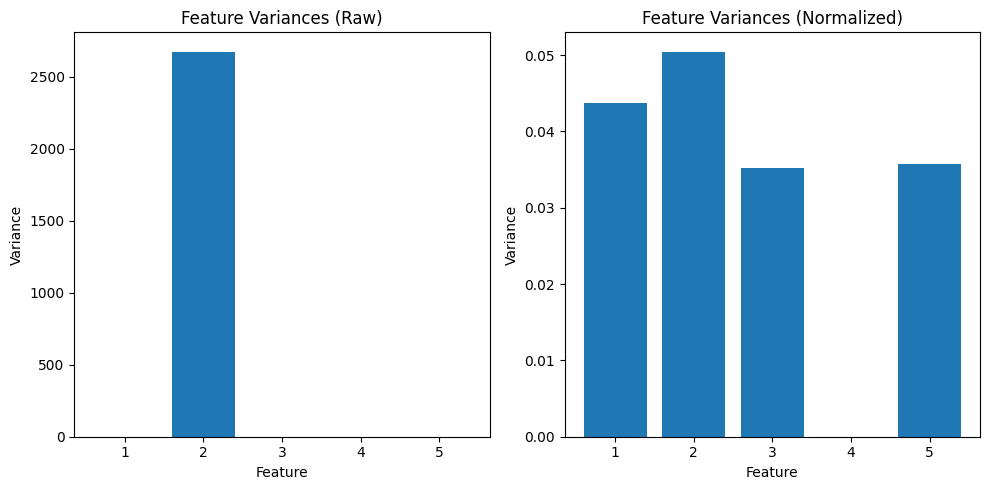

In [7]:
variances_raw = np.var(X, axis=0)
variances_norm = np.var(X_norm, axis=0)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, 6), variances_raw)
plt.title("Feature Variances (Raw)")
plt.xlabel("Feature")
plt.ylabel("Variance")

plt.subplot(1, 2, 2)
plt.bar(range(1, 6), variances_norm)
plt.title("Feature Variances (Normalized)")
plt.xlabel("Feature")
plt.ylabel("Variance")

plt.tight_layout()
plt.show()